In [19]:
import pandas as pd
import numpy as np

data_dir = "../../data/raw"

customers = pd.read_csv(data_dir + "/customers.csv")
orders = pd.read_csv(data_dir + "/orders.csv")
products = pd.read_csv(data_dir + "/products.csv")
order_items = pd.read_csv(data_dir + "/order_items.csv")

customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   gender       150 non-null    str  
 3   age          150 non-null    int64
 4   city         150 non-null    str  
 5   signup_date  150 non-null    str  
dtypes: int64(2), str(4)
memory usage: 11.0 KB


In [20]:
from matplotlib import font_manager

installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ["Malgun Gothic", "AppleGothic", "Apple SD Gothic Neo", "Noto Sans CJK KR", "NanumGothic"]

In [21]:
import matplotlib.pyplot as plt

korean_font = korean_font = next(
    (name for name in font_candidates if name in installed_fonts), None
)

print(korean_font)

if korean_font:
    plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

Malgun Gothic


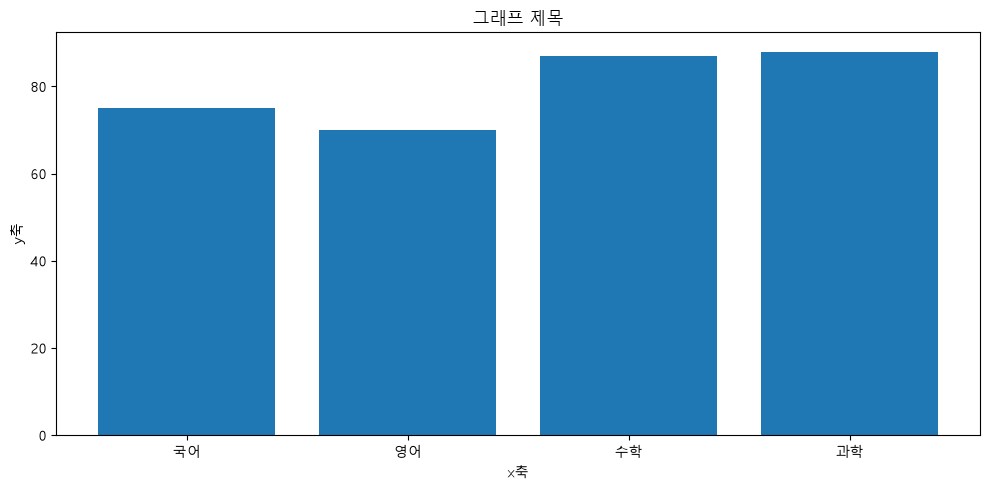

In [22]:
import matplotlib.pyplot as plt

x_data = ["국어", "영어", "수학", "과학"]
y_data = [75, 70, 87, 88]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_data, y_data)
ax.set_title("그래프 제목")
ax.set_xlabel("x축")
ax.set_ylabel("y축")
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(
    "graph.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [23]:
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="raise")
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        300 non-null    int64         
 1   customer_id     300 non-null    int64         
 2   order_date      300 non-null    datetime64[us]
 3   payment_method  300 non-null    str           
 4   order_status    300 non-null    str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 17.0 KB


In [28]:
products_cleaned = pd.read_csv("../../data/processed/products_clean.csv")

df_visualization = pd.read_csv("../../data/processed/visualization.csv")

In [29]:
df_visualization.head()

,order_item_id,order_id,customer_id,product_id,order_date,order_month,order_dayofweek,payment_method,order_status,gender,...,product_name,category,price,quantity,unit_price,line_total,order_match,product_match,customer_match,merge_valid
0,1,1,144.0,39,2026-07-12,2026-07,Sunday,naver_pay,completed,F,...,뷰티 상품 039,뷰티,172000.0,2.0,172000.0,344000.0,True,True,True,True
1,2,2,149.0,26,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,뷰티 상품 026,뷰티,79000.0,4.0,79000.0,316000.0,True,True,True,True
2,3,2,149.0,46,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,생활용품 상품 046,생활용품,87000.0,3.0,87000.0,261000.0,True,True,True,True
3,4,2,149.0,80,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,패션 상품 080,패션,187000.0,1.0,187000.0,187000.0,True,True,True,True
4,5,2,149.0,91,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,전자기기 상품 091,전자기기,125000.0,5.0,125000.0,625000.0,True,True,True,True


In [40]:
category_sales =  df_visualization.assign(category=df_visualization["category"].fillna("미분류")).groupby("category", dropna=False, as_index=False).agg(
    total_amount = ("line_total", sum),
    total_quantity = ("quantity", sum),

).sort_values("total_amount", ascending=False)

category_sales

,category,total_amount,total_quantity
10,패션,64890000.0,545.0
7,식품,47044000.0,394.0
9,전자기기,37542000.0,303.0
3,뷰티,28614000.0,282.0
0,도서,28246000.0,277.0
6,스포츠,20651000.0,254.0
5,생활용품,14303000.0,213.0
1,미분류,6224000.0,65.0
4,생활 용품,3348000.0,27.0
2,뷰 티,1026000.0,19.0


(0.0, 68134500.0)

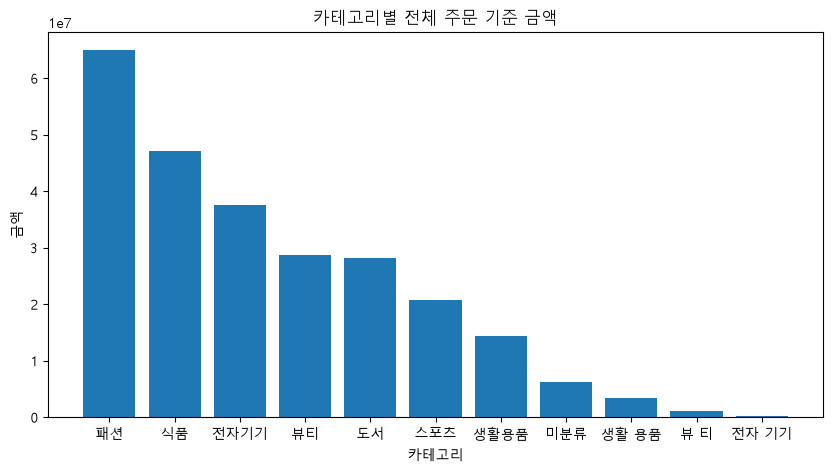

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    category_sales["category"],
    category_sales["total_amount"],
)
ax.set_title("카테고리별 전체 주문 기준 금액")
ax.set_xlabel("카테고리")
ax.set_ylabel("금액")
ax.set_ylim(bottom=0)

In [43]:
monthly_sales = df_visualization.groupby(df_visualization["order_month"], as_index=False).agg(
    total_amount = ("line_total", "sum"),
    order_count = ("order_id", "nunique")
).sort_index()

monthly_sales

,order_month,total_amount,order_count
0,2025-07,13729000.0,19
1,2025-08,32639000.0,25
2,2025-09,13058000.0,12
3,2025-10,16680000.0,22
4,2025-11,15080000.0,23
5,2025-12,16152000.0,23
6,2026-01,19053000.0,26
7,2026-02,14207000.0,19
8,2026-03,13841000.0,22
9,2026-04,21007000.0,26


Text(0, 0.5, '금액')

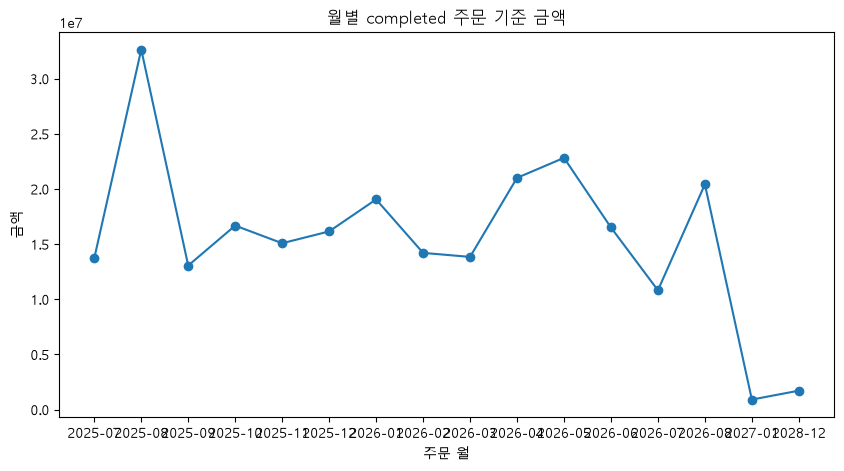

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    monthly_sales["order_month"],
    monthly_sales["total_amount"],
    marker="o",
)

ax.set_title("월별 completed 주문 기준 금액")
ax.set_xlabel("주문 월")
ax.set_ylabel("금액")

Text(0, 0.5, '상품 수')

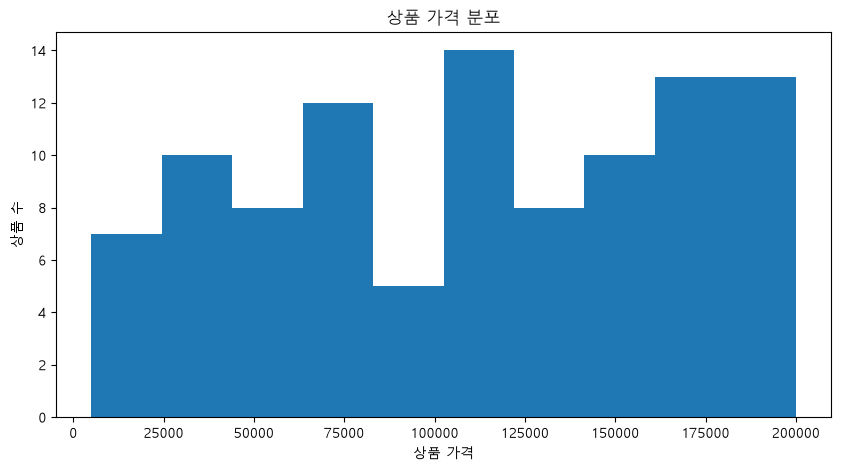

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    products["price"],
    bins=10,
)

ax.set_title("상품 가격 분포")
ax.set_xlabel("상품 가격")
ax.set_ylabel("상품 수")

In [49]:
product_sales = df_visualization.groupby("product_id", as_index=False).agg(
    total_quantity = ("quantity", "sum"),
    total_amount = ("line_total", "sum")
)

Text(0, 0.5, 'completed 판매 수량')

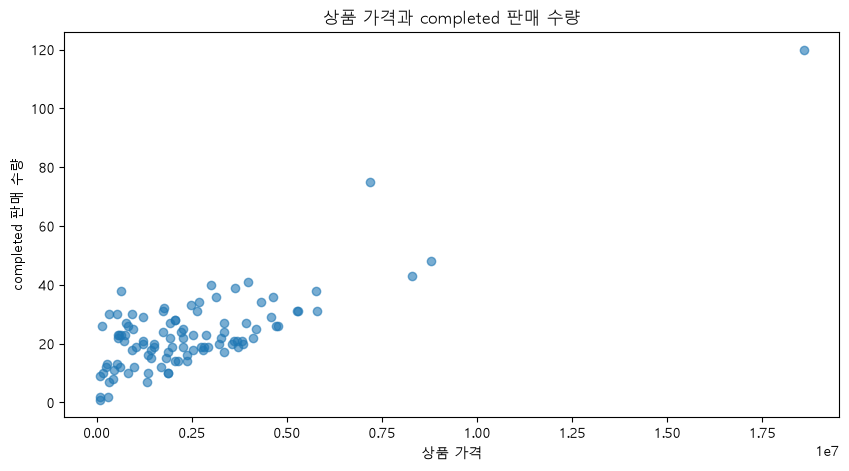

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    product_sales["total_amount"],
    product_sales["total_quantity"],
    alpha=0.6,
)

ax.set_title("상품 가격과 completed 판매 수량")
ax.set_xlabel("상품 가격")
ax.set_ylabel("completed 판매 수량")

In [52]:
customer_sales = df_visualization.groupby("customer_id", dropna=False, as_index=False).agg(
    total_amount = ("line_total", "sum"),
    order_count = ("order_id", "nunique")
).sort_values("total_amount", ascending=False)


In [57]:
top_customers = customer_sales.head(10).reset_index(drop=True)
print(top_customers)

   customer_id  total_amount  order_count
0         18.0    16666000.0            2
1          3.0     8909000.0            7
2         20.0     6200000.0            6
3         52.0     5388000.0            5
4         14.0     5204000.0            4
5         22.0     5029000.0            4
6         55.0     4850000.0            6
7         90.0     4847000.0            5
8         15.0     4281000.0            5
9         93.0     4001000.0            4


<BarContainer object of 10 artists>

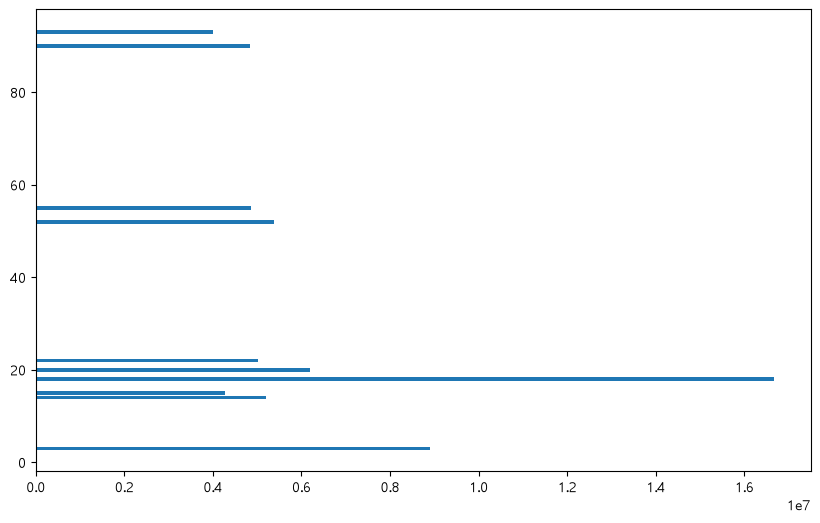

In [59]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_customers["customer_id"],
    top_customers["total_amount"],
)